In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  
from scipy.special import gamma
import gc
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.colors import ListedColormap


In [2]:
delta_sst = 0
path_folder = "~/projects/def-rfajber/philbou/saved_ds/"
#path_folder = "./"
base_folder_name = "RT42_sst_"


exp_folder_name = f"{base_folder_name}{'m' + str(abs(delta_sst)) if delta_sst < 0 else str(delta_sst)}_bucket"
path = f"{path_folder}/{exp_folder_name}"

ds_age = xr.open_dataset(f"{path}/age.nc")
ds_mix = xr.open_dataset(f"{path}/mixed_layer.nc",decode_times = False)
ds_dyn = xr.open_dataset(f"{path}/dynamics.nc")
ds_atm = xr.open_dataset(f"{path}/atmosphere.nc")
ds_precip_age = xr.open_dataset(f"{path}/precipitation_age.nc")
ds_data_6h = xr.open_dataset(f"{path}/data_6h.nc")
ds_rad = xr.open_dataset(f"{path}/rrtm_rad.nc")

ds_age["time"] = np.arange(0,len(ds_age.time.values),1)
ds_dyn["time"] = np.arange(0,len(ds_dyn.time.values),1)
ds_rad["time"] = np.arange(0,len(ds_rad.time.values),1)
ds_atm["time"] = np.arange(0,len(ds_atm.time.values),1)
ds_mix["time"] = np.arange(0,len(ds_mix.time.values),1)
ds_precip_age["time"] = np.arange(0,len(ds_precip_age.time.values),1)


land_mask_name = "era_land_t42.nc"
lm_path = "~/Isca/exp/test_cases/realistic_continents/input/"+land_mask_name
ds_landmask= xr.open_dataset(lm_path) 
land_mask = ds_landmask.land_mask.values

In [40]:
q = ds_data_6h.sphum
ps = ds_data_6h.ps.mean("time")
qT = ds_data_6h.sphum_age_1
T = (qT/q)/(24*60**2)
lon = ds_data_6h.lon.values
pfull = ds_data_6h.pfull
phalf = ds_data_6h.phalf
lat = ds_data_6h.lat.values
temp = ds_dyn.temp

theta = dps.get_pot_temp(temp,pfull,ps)

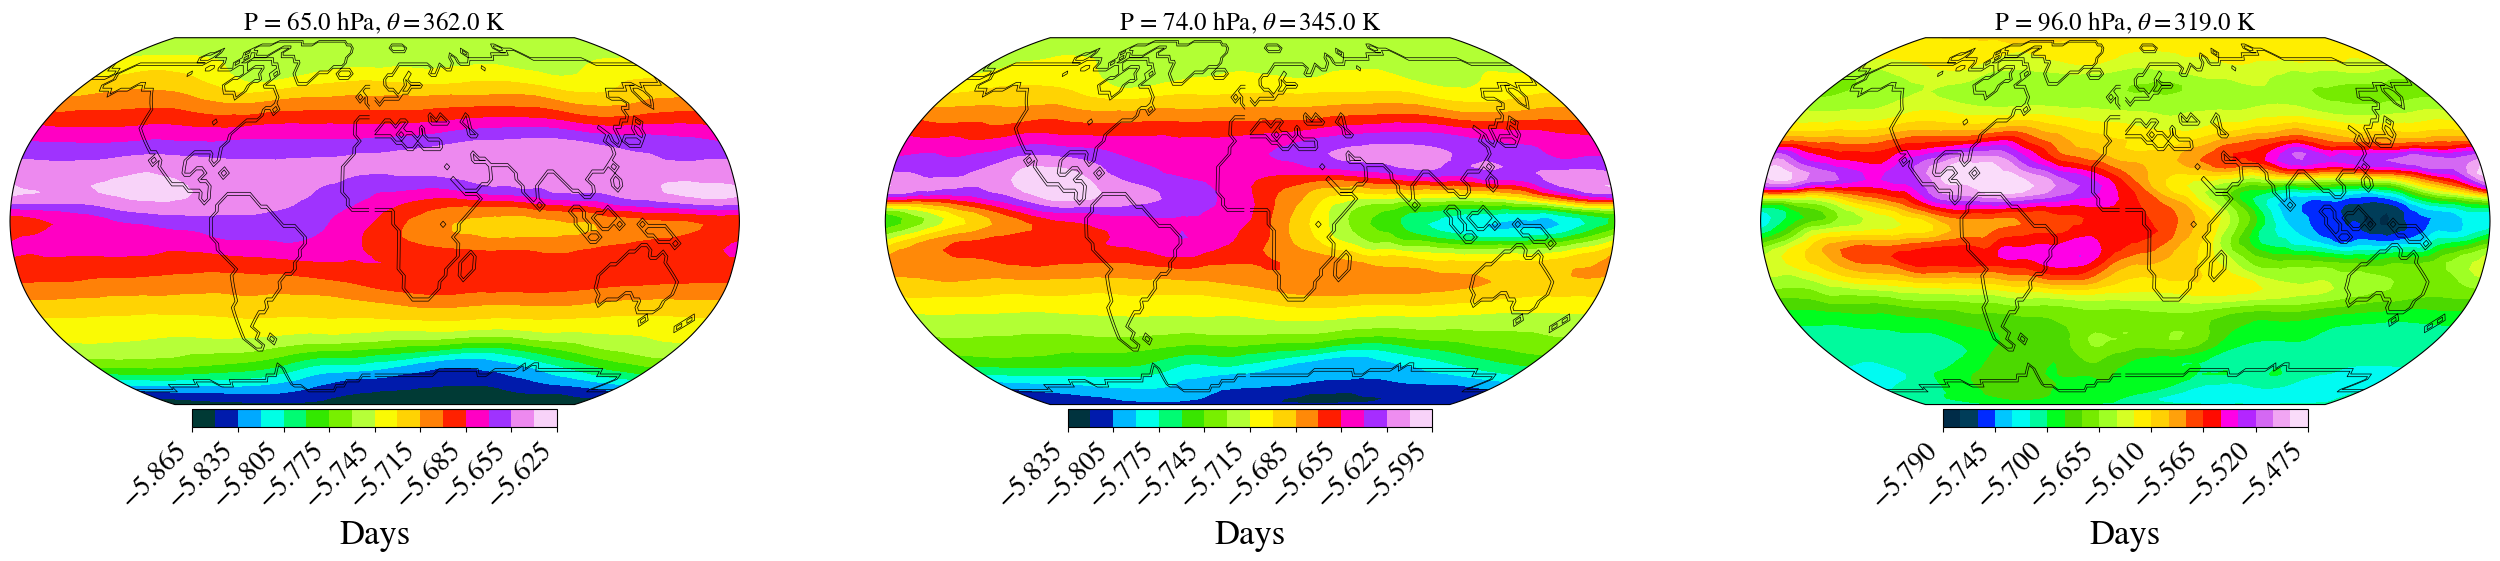

In [106]:
fig, ax = plt.subplots(1,3,figsize = (32,6),subplot_kw={'projection': ccrs.Robinson()})
k=0
for p in [11,12,14]:
    theta_t = np.mean(theta,axis =0)[p,:,:]
    tmp = dps.scan_2d(q.isel(pfull = p).mean(dim = "time"),ps/100,pfull[p].values)
    cbar = dps.plot_2d(np.log10(tmp.values),lat,lon,ax[k],"gist_ncar",level_space=20,land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "neither")
    cbar.set_label("Days",fontsize = 25,labelpad = 5)
    ax[k].set_title(f"P = {np.round(pfull[p].values,0)} hPa, $\\theta = ${np.round(theta_t[43,32],0)} K")
    k+=1

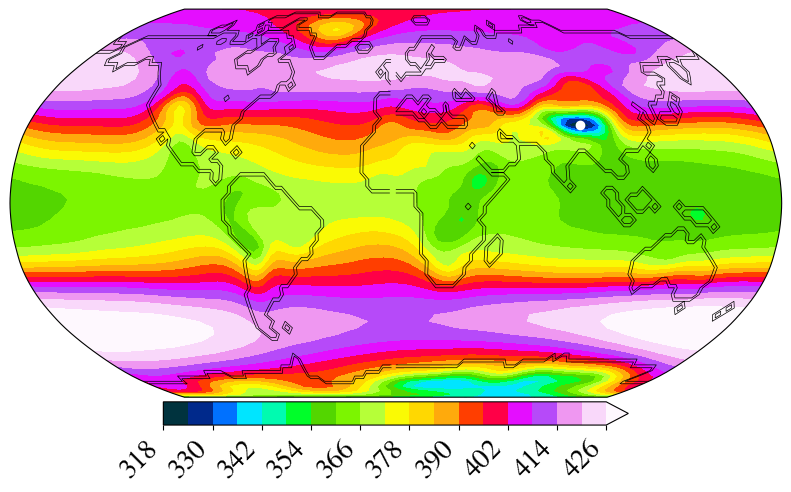

In [93]:
fig, ax = plt.subplots(1,1,figsize = (12,6),subplot_kw={'projection': ccrs.Robinson()})

cbar = dps.plot_2d(theta_t,lat,lon,ax,"gist_ncar",level_space=20,land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax.scatter(lon[32],lat[43],transform = ccrs.PlateCarree(),color = "w")

In [50]:
ds_pre_m1 = xr.open_mfdataset("~/projects/def-rfajber/philbou/saved_ds//RT42_sst_m1_bucket/precipitation_age.nc")
ds_pre_m2 = xr.open_mfdataset("~/projects/def-rfajber/philbou/saved_ds//RT42_sst_m2_bucket/precipitation_age.nc")
ds_pre_m3 = xr.open_mfdataset("~/projects/def-rfajber/philbou/saved_ds//RT42_sst_m3_bucket/precipitation_age.nc")

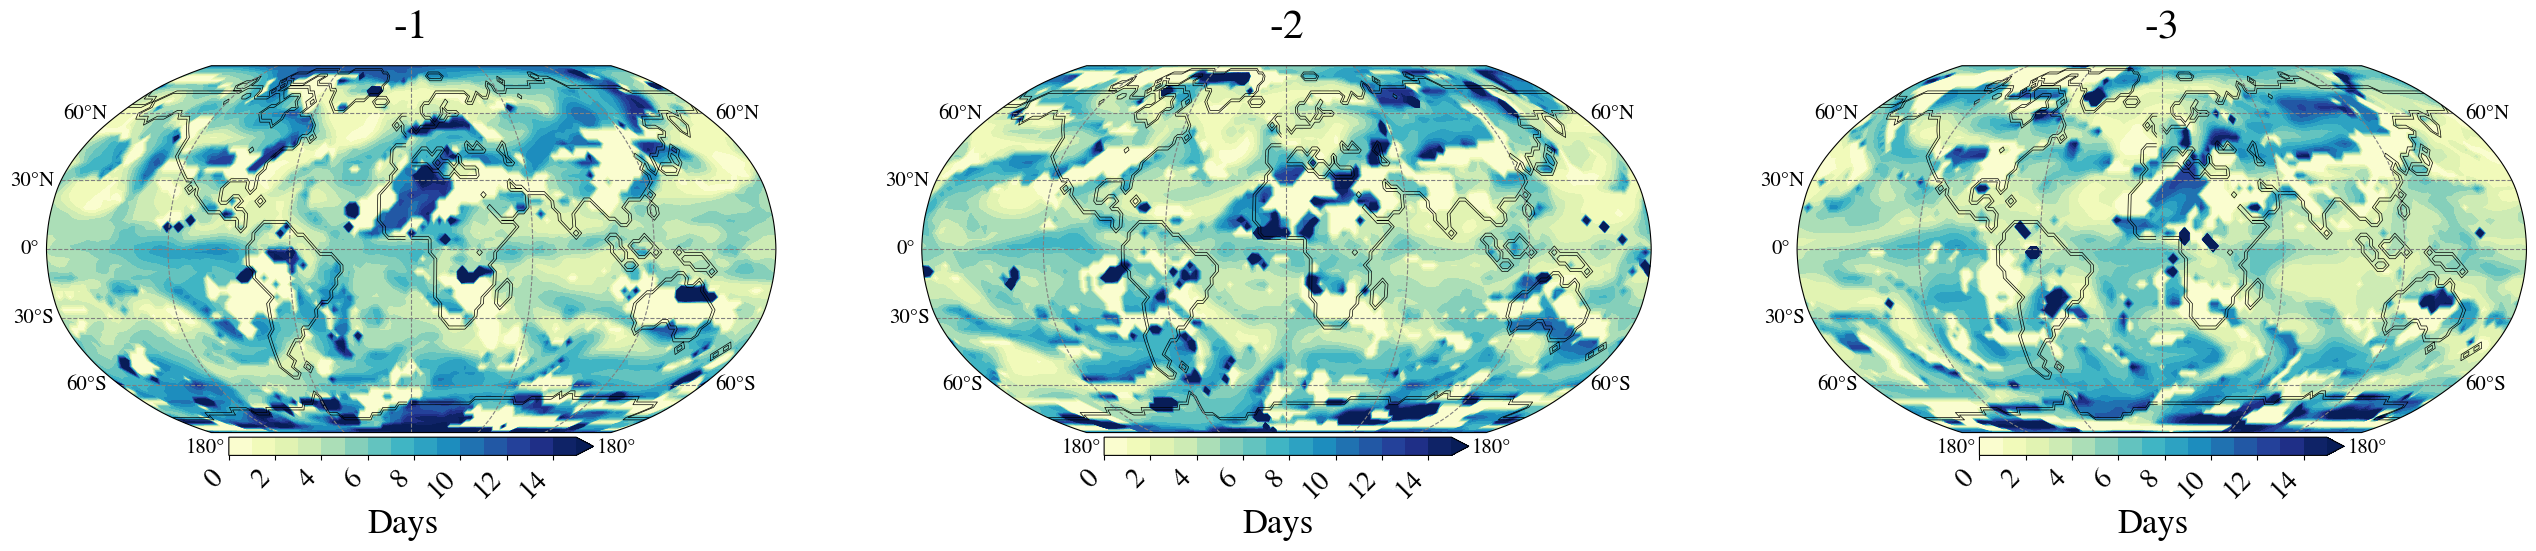

In [54]:
fig, ax = plt.subplots(1,3,figsize = (32,6),subplot_kw={'projection': ccrs.Robinson()})

ti = -2
precip_agem1 = ds_pre_m1.precip_age.isel(time = ti)
precip_agem2 = ds_pre_m2.precip_age.isel(time = ti)
precip_agem3 = ds_pre_m3.precip_age.isel(time = ti)

lat = ds_precip_age.lat
lon = ds_precip_age.lon
ax_age_vert = ax[0]
cbar = dps.plot_2d((precip_agem1).values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,16),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("-1",fontsize = 30,pad = 20)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_vert = ax[1]
cbar = dps.plot_2d((precip_agem2).values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,16),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("-2",fontsize = 30,pad = 20)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_vert = ax[2]
cbar = dps.plot_2d((precip_agem3).values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,16),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("-3",fontsize = 30,pad = 20)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False




In [42]:
area = dps.get_area(ds_age)



dps.area_w_avg(area,precip_agem1.values)/(24*60**2), dps.area_w_avg(area,precip_agem2.values)/(24*60**2)

(5.258836247630514, 5.253488122993204)

In [60]:
dd = xr.open_mfdataset("/home/philbou/Isca/exp/test_cases/realistic_continents/input/sst_clim_amip(2).nc",decode_times = False)

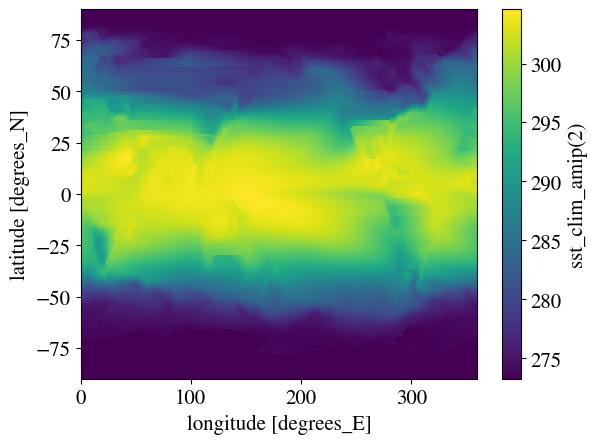

In [63]:
dd["sst_clim_amip(2)"].mean("time").plot()

/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


(200.0, 0.0)

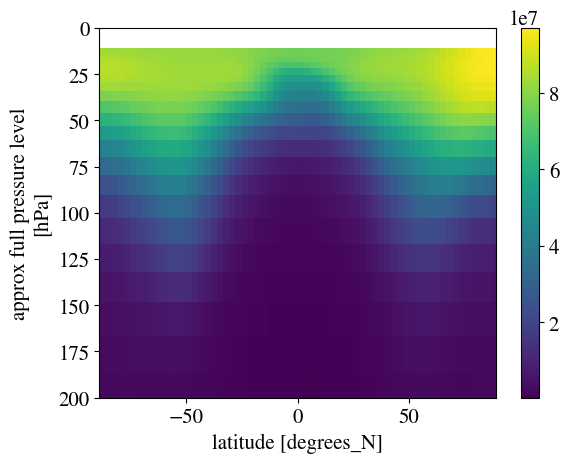

In [5]:
ds = xr.open_mfdataset("/home/philbou/scratch/isca_data/RT42_sst_2_bucket/run0360/atmos_monthly.nc")
q = ds.sphum
sphum = ds.sphum
qmoments = [ds.sphum_age_1,ds.sphum_age_2]
moments = [qmoments[0]/sphum,qmoments[1]/sphum]
mean = moments[0].mean(dim = "lon")
mean.mean("time").plot()
plt.ylim(200,0)

In [113]:
ds

<xarray.Dataset>
Dimensions:             (lon: 128, lonb: 129, lat: 64, latb: 65, time: 120,
                         nv: 2, phalf: 46, pfull: 45)
Coordinates:
  * lon                 (lon) float64 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * lonb                (lonb) float64 -1.406 1.406 4.219 ... 353.0 355.8 358.6
  * lat                 (lat) float64 -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * latb                (latb) float64 -90.0 -86.58 -83.76 ... 83.76 86.58 90.0
  * time                (time) object 0030-02-01 03:00:00 ... 0030-02-30 21:0...
  * nv                  (nv) float64 1.0 2.0
  * phalf               (phalf) float64 11.11 13.14 15.5 ... 964.3 985.3 1e+03
  * pfull               (pfull) float64 12.11 14.3 16.85 ... 951.3 974.8 992.6
Data variables: (12/43)
    ps                  (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    bk                  (phalf) float32 dask.array<chunksize=(46,), meta=np.ndarray>
    pk                  (phalf) float32 dask.array<chunksize=(46,), meta=np.ndarray>
    precipitation       (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    t_surf              (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    flux_lhe            (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    ...                  ...
    flux_sw             (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    flux_lw             (time, lat, lon) float32 dask.array<chunksize=(120, 64, 128), meta=np.ndarray>
    average_T1          (time) object dask.array<chunksize=(120,), meta=np.ndarray>
    average_T2          (time) object dask.array<chunksize=(120,), meta=np.ndarray>
    average_DT          (time) timedelta64[ns] dask.array<chunksize=(120,), meta=np.ndarray>
    time_bounds         (time, nv) timedelta64[ns] dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes:
    filename:   /scratch/philbou/isca_work/experiment/RT42_sst_2_bucket/run/a...
    title:      FMS Model results
    grid_type:  regular
    grid_tile:  N/A

(900.0, 0.0)

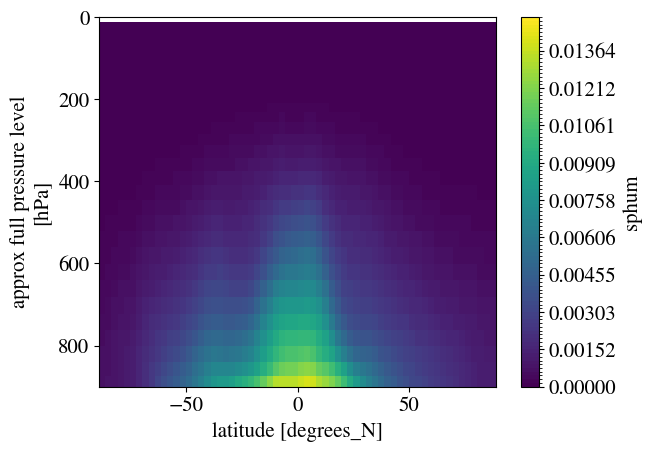

In [6]:
#ds.sphum.mean(dim = "lon").isel(time = -75).plot(levels = np.linspace(0,0.015,100),extend = "neither")
ds.sphum.mean(dim = ["lon","time"]).plot(levels = np.linspace(0,0.015,100),extend = "neither")


plt.ylim(900,0)

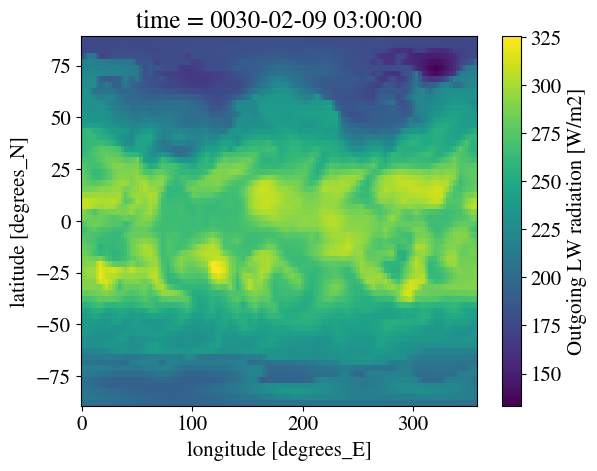

In [75]:
ds.olr.isel(time = -88).plot()